<a href="https://colab.research.google.com/github/Rosamii1/cpython/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


In [ ]:
from google.colab import files
from PIL import Image as PILImage

In [ ]:
location = ""

civic_questions = [
    ("FIND LOCATION", f"At {location}, what property problems does this plot of land face?"),
    ("PROBLEM",  "Can you help me identify the problem, is it limited housing with spiking prices or something else?"),
    ("TRANSIT",  "Can you help me identify what type of transit is near this land"),
    ("IMPACT",   "What are the community impacts of the land owning?"),
    ("AREA TYPE", "What type of area is this image, is it suburban, urban, or downtown?"),
    ("ACTION",   "What act of plan should the government try to convey to this landownder?")
]

civic_results = {"answers": {}, "total_tokens": 0}

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

In [ ]:
def get_completion(prompt, system_instruction="You are a helpful assistant.", max_retries=3):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction
    )

    retries = 0
    while retries < max_retries:
        try:
            response = m.generate_content(question)
            time.sleep(12)  # stays under free tier rate limit (5 requests/min)
            return response.text
        except TooManyRequests as e:
            retries += 1
            if retries == max_retries:
                raise e # Re-raise if max retries reached

            # Extract retry time from the error message
            match = re.search(r'Please retry in (\d+\.?\d*)s\.', str(e))
            wait_time = 60 # Default wait time if not found
            if match:
                wait_time = float(match.group(1))

            print(f"Quota exceeded. Retrying in {wait_time:.2f} seconds... (Attempt {retries}/{max_retries})")
            time.sleep(wait_time + 1) # Add a small buffer
        except Exception as e:
            # Handle other potential errors
            raise e

    # Should not reach here if max_retries is handled correctly
    return ""

In [ ]:
def get_completion_img(image_path, prompt, system_instruction="You are a helpful assistant.", max_retries=3):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction
    )

    img = PILImage.open(image_path)


    retries = 0
    while retries < max_retries:
        try:
            response = m.generate_content([question, img])
            time.sleep(12)  # stays under free tier rate limit (5 requests/min)
            return response.text
        except TooManyRequests as e:
            retries += 1
            if retries == max_retries:
                raise e # Re-raise if max retries reached

            # Extract retry time from the error message
            match = re.search(r'Please retry in (\d+\.?\d*)s\.', str(e))
            wait_time = 60 # Default wait time if not found
            if match:
                wait_time = float(match.group(1))

            print(f"Quota exceeded. Retrying in {wait_time:.2f} seconds... (Attempt {retries}/{max_retries})")
            time.sleep(wait_time + 1) # Add a small buffer
        except Exception as e:
            # Handle other potential errors
            raise e

    # Should not reach here if max_retries is handled correctly
    return ""

Upload image of location on a map from your computer.


Saving Screenshot_2026-05-09_215636.PNG to Screenshot_2026-05-09_215636.PNG
Uploaded: Screenshot_2026-05-09_215636.PNG
Image size: 922x693 pixels


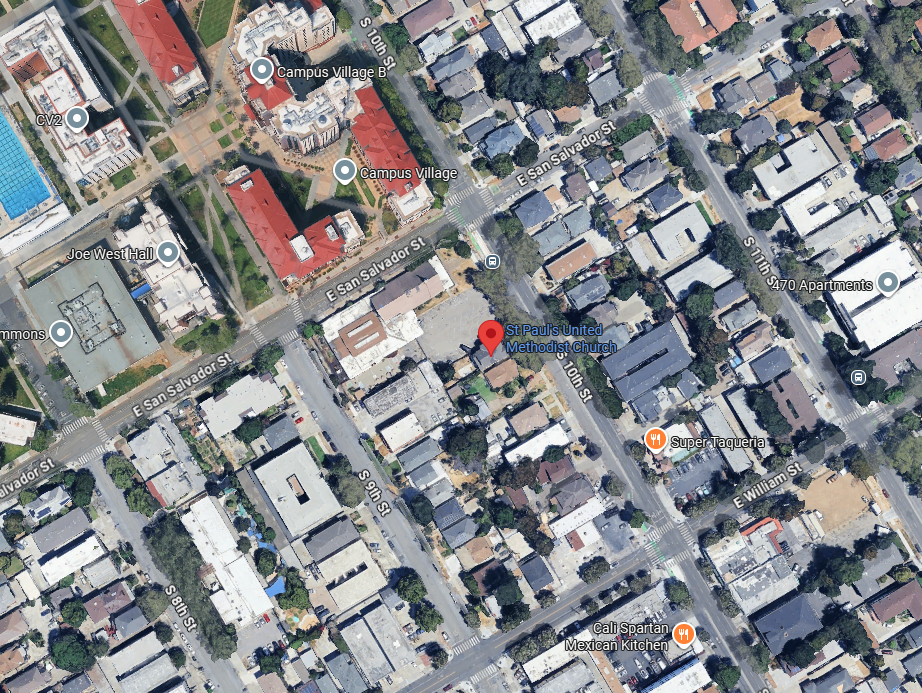

In [ ]:
# Upload your image from your computer.
print("Upload image of location on a map from your computer.")
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

location = {input("Please specify the location on this map.")}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()
    import time
    # Increase sleep to ensure we stay under the free tier rate limit.
    # The error message suggests retrying, so a longer sleep is needed.
    # analyze_image already has a 12 second sleep, so we add 60 seconds here for a total of 72 seconds per call.
    time.sleep(60)

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")


In [ ]:
while True:
  prompt = input("Do you have any other questions about this location? (Type n to cancel) ")
  response = get_completion(answer, system_instruction=prompt)
  # response = get_completion_img(image_path=image_filename, prompt=prompt, system_instruction=answer)
  print("\n--- AI Response ---")
  print(response)

  if prompt == "n":
    break